In [154]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Show all columns when displaying DataFrames
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [155]:
import pandas as pd

# Load all cleaned datasets
fund = pd.read_csv("../data/processed/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [156]:
datasets = {
    "Fund Master": fund,
    "NAV History": nav,
    "AUM": aum,
    "Monthly SIP": sip,
    "Category Inflows": category,
    "Folio Count": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
Monthly SIP: (48, 6)
Category Inflows: (144, 3)
Folio Count: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [157]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [158]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [159]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [160]:
sip.head()


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [161]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [162]:
fund.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [163]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [164]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [165]:
sip.info()


<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [166]:
performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ratio_pct   4

In [167]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.isnull().sum())
    print()

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV History
amfi_code    0
date         0
nav          0
dtype: int64

AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

Monthly SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Category Inflows
month               0
category            0
net_inflow_crore    0
dtype: int64

Folio Count
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      

In [168]:
for name, df in datasets.items():
    print("\n", "="*60)
    print(name)
    print("="*60)
    print(df.dtypes)


Fund Master
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object

NAV History
amfi_code      int64
date             str
nav          float64
dtype: object

AUM
date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

Monthly SIP
month                            str
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

Category Inflows
month            

In [169]:
fund.describe(include="all")

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
count,40.000000,40,40,40,40,40,40,40,40.000000,40.000000,40.0,40.000000,40,40,40
unique,NaN,10,40,2,12,2,34,10,NaN,NaN,NaN,NaN,29,5,9
top,NaN,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2013-01-01,NIFTY 100 TRI,NaN,NaN,NaN,NaN,Sohini Andani,Moderate,EC01
freq,NaN,5,1,34,14,32,7,14,NaN,NaN,NaN,NaN,2,16,14
mean,120247.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.237000,0.812500,500.0,1277.500000,NaN,NaN,NaN
std,14534.998667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386584,0.387091,0.0,1082.847031,NaN,NaN,NaN
min,100016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.550000,0.000000,500.0,100.000000,NaN,NaN,NaN
25%,118632.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.787500,1.000000,500.0,1000.000000,NaN,NaN,NaN
50%,119551.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.425000,1.000000,500.0,1000.000000,NaN,NaN,NaN
75%,120842.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.540000,1.000000,500.0,1000.000000,NaN,NaN,NaN


In [170]:
aum.describe(include="all")

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
count,90,90,90.000000,9.000000e+01,90.000000
unique,9,10,NaN,NaN,NaN
top,2022-03-31,SBI Mutual Fund,NaN,NaN,NaN
freq,10,9,NaN,NaN,NaN
mean,NaN,NaN,4.352889,4.352889e+05,152.200000
std,NaN,NaN,2.734328,2.734328e+05,52.108832
min,NaN,NaN,1.050000,1.050000e+05,56.000000
25%,NaN,NaN,2.525000,2.525000e+05,95.000000
50%,NaN,NaN,3.450000,3.450000e+05,172.500000
75%,NaN,NaN,5.675000,5.675000e+05,195.000000


In [171]:
nav.describe(include="all")

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
unique,NaN,1150,NaN
top,NaN,2022-01-03,NaN
freq,NaN,40,NaN
mean,120247.000000,NaN,269.570265
std,14352.317221,NaN,577.187060
min,100016.000000,NaN,26.136600
25%,118632.750000,NaN,69.170425
50%,119551.500000,NaN,122.732150
75%,120842.250000,NaN,260.338675


In [172]:
sip.describe(include="all")

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48,48.000000,48.000000,48.000000,48.000000,36.000000
unique,48,NaN,NaN,NaN,NaN,NaN
top,2022-01,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,19577.520833,7.189583,9.893750,8.632083,31.456944
std,NaN,6354.329621,1.271457,5.370745,3.613579,11.768190
min,NaN,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,NaN,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,NaN,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,NaN,25944.250000,8.300000,9.562500,10.525000,40.807500


In [173]:
performance.describe(include="all")

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
count,40.000000,40,40,40,40,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000,40
unique,NaN,40,10,12,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,NaN,1,5,14,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
mean,120247.000000,NaN,NaN,NaN,NaN,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000,NaN
std,14534.998667,NaN,NaN,NaN,NaN,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484,NaN
min,100016.000000,NaN,NaN,NaN,NaN,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000,NaN
25%,118632.750000,NaN,NaN,NaN,NaN,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000,NaN
50%,119551.500000,NaN,NaN,NaN,NaN,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000,NaN
75%,120842.250000,NaN,NaN,NaN,NaN,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000,NaN


In [174]:
print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [175]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [176]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [177]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [178]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [179]:
for name, df in datasets.items():

    print(name)

    print("Rows :",df.shape[0])

    print("Columns :",df.shape[1])

    print("Duplicates :",df.duplicated().sum())

    print("Missing :",df.isnull().sum().sum())

    print()

Fund Master
Rows : 40
Columns : 15
Duplicates : 0
Missing : 0

NAV History
Rows : 46000
Columns : 3
Duplicates : 0
Missing : 0

AUM
Rows : 90
Columns : 5
Duplicates : 0
Missing : 0

Monthly SIP
Rows : 48
Columns : 6
Duplicates : 0
Missing : 12

Category Inflows
Rows : 144
Columns : 3
Duplicates : 0
Missing : 0

Folio Count
Rows : 21
Columns : 6
Duplicates : 0
Missing : 0

Performance
Rows : 40
Columns : 19
Duplicates : 0
Missing : 0

Transactions
Rows : 32778
Columns : 13
Duplicates : 0
Missing : 0

Holdings
Rows : 322
Columns : 8
Duplicates : 0
Missing : 0

Benchmark
Rows : 8050
Columns : 3
Duplicates : 0
Missing : 0



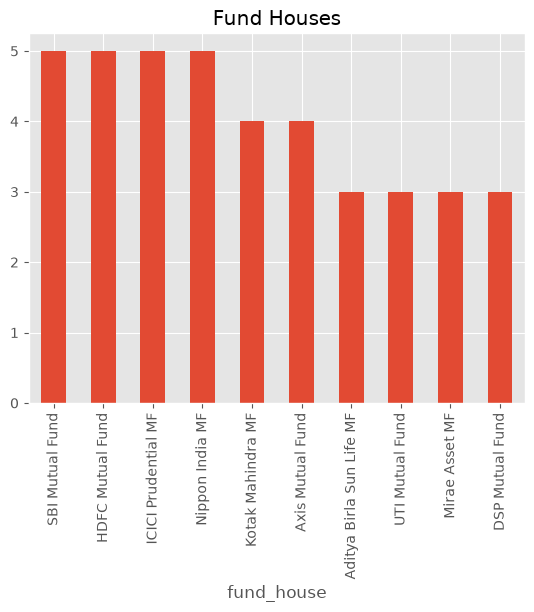

In [180]:
fund["fund_house"].value_counts().plot(kind="bar")

plt.title("Fund Houses")

plt.show()

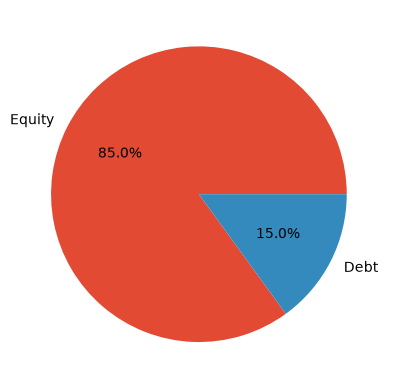

In [181]:
fund["category"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.show()

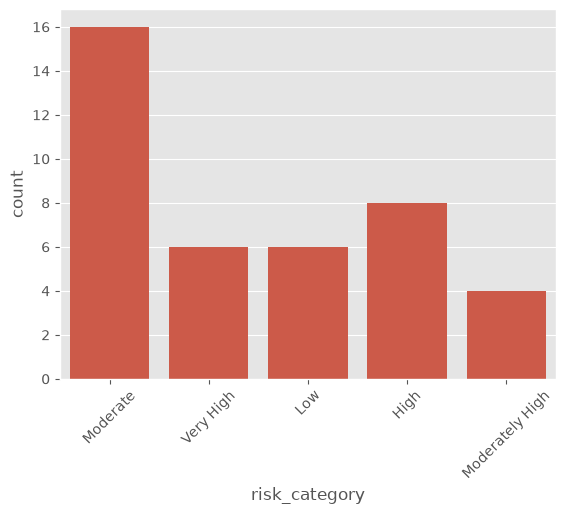

In [182]:
sns.countplot(data=fund,x="risk_category")

plt.xticks(rotation=45)

plt.show()

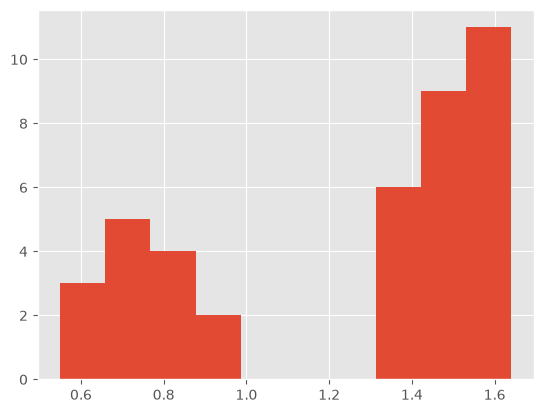

In [183]:
plt.hist(fund["expense_ratio_pct"])

plt.show()

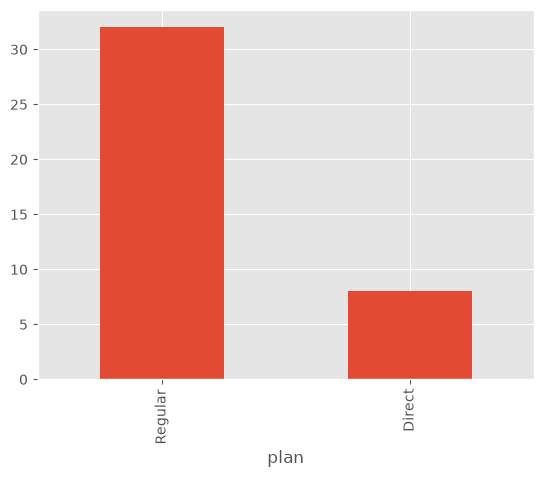

In [184]:
fund["plan"].value_counts().plot(kind="bar")

plt.show()

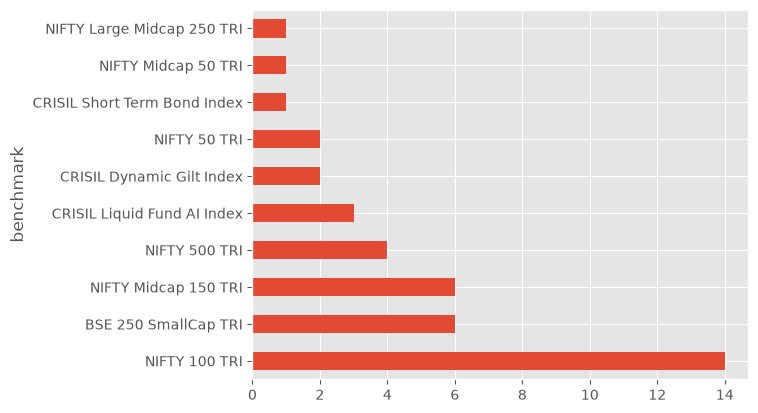

In [185]:
fund["benchmark"].value_counts().plot(kind="barh")

plt.show()

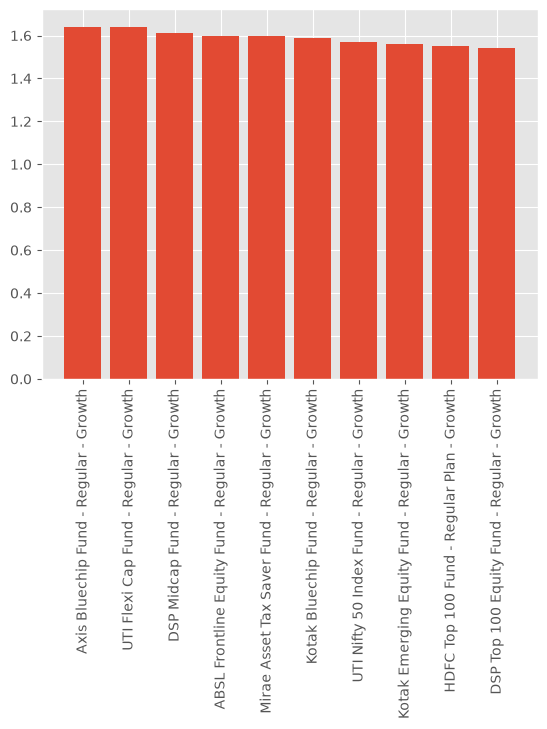

In [186]:
top = fund.sort_values(
"expense_ratio_pct",
ascending=False
).head(10)

plt.bar(top["scheme_name"],top["expense_ratio_pct"])

plt.xticks(rotation=90)

plt.show()

In [187]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [188]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"], dayfirst=True)

# Average NAV for each date
nav_trend = nav.groupby("date")["nav"].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(nav_trend["date"], nav_trend["nav"], linewidth=2)

plt.title("Average NAV Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.grid(True)

plt.show()

ValueError: unconverted data remains when parsing with format "%Y-%d-%m": "3". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [189]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [190]:
nav[["date"]].head(20)

,date
0,2022-01-03
1,2022-01-04
2,2022-01-05
3,2022-01-06
4,2022-01-07
5,2022-01-10
6,2022-01-11
7,2022-01-12
8,2022-01-13
9,2022-01-14


In [191]:
nav["date"] = pd.to_datetime(nav["date"], format="mixed", errors="coerce")

In [192]:
nav["date"] = pd.to_datetime(nav["date"], format="%Y-%d-%m")

In [193]:
print(nav["date"].head(10))

0   2022-01-03
1   2022-01-04
2   2022-01-05
3   2022-01-06
4   2022-01-07
5   2022-01-10
6   2022-01-11
7   2022-01-12
8   2022-01-13
9   2022-01-14
Name: date, dtype: datetime64[us]


In [194]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


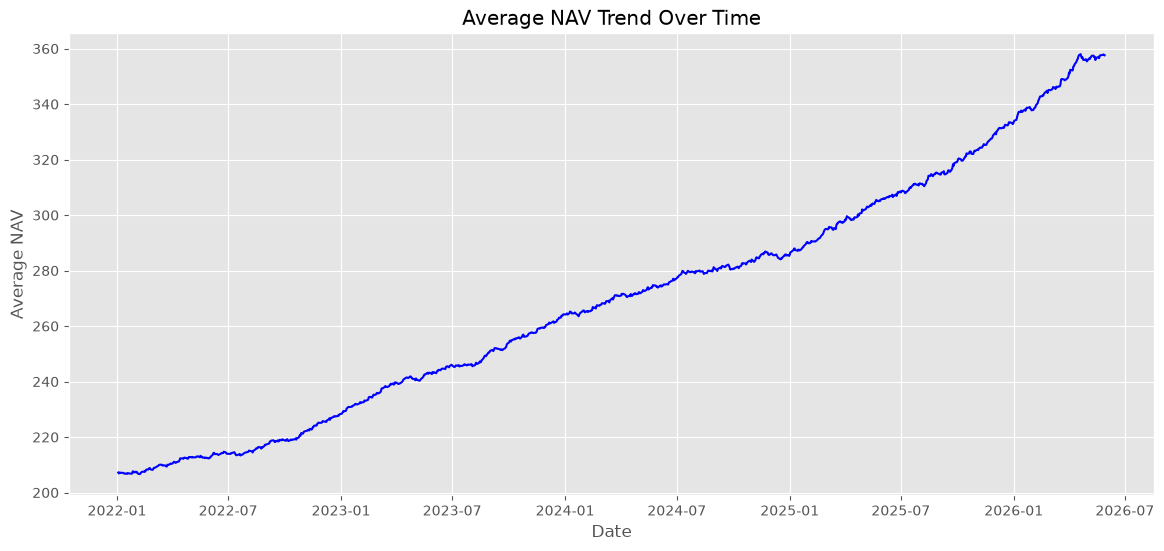

In [195]:
# Average NAV for each date
nav_trend = nav.groupby("date")["nav"].mean().reset_index()

plt.figure(figsize=(14,6))

plt.plot(nav_trend["date"], nav_trend["nav"], color="blue")

plt.title("Average NAV Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Average NAV")

plt.grid(True)

plt.show()

In [197]:
# Set date as index
nav.set_index("date", inplace=True)

# Monthly average NAV
monthly_nav = nav["nav"].resample("ME").mean()

plt.figure(figsize=(14,6))

plt.plot(monthly_nav)

plt.title("Monthly Average NAV Trend")

plt.xlabel("Month")

plt.ylabel("Average NAV")

plt.grid(True)

plt.show()

KeyError: "None of ['date'] are in the columns"

In [198]:
print(nav.columns.tolist())
print(nav.index)

['amfi_code', 'nav']
DatetimeIndex(['2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06',
               '2022-01-07', '2022-01-10', '2022-01-11', '2022-01-12',
               '2022-01-13', '2022-01-14',
               ...
               '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21',
               '2026-05-22', '2026-05-25', '2026-05-26', '2026-05-27',
               '2026-05-28', '2026-05-29'],
              dtype='datetime64[us]', name='date', length=46000, freq=None)


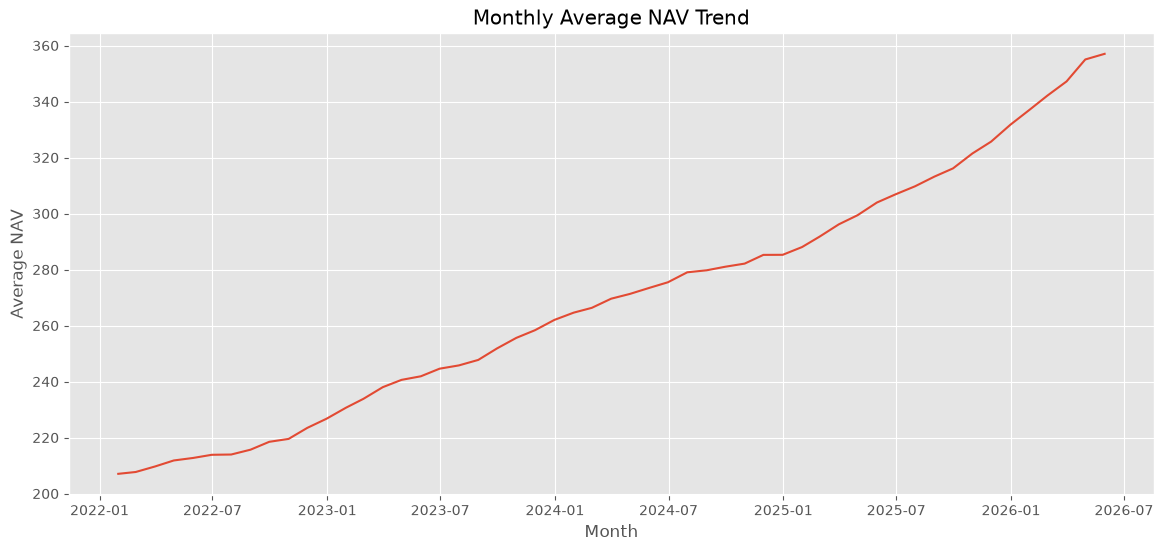

In [199]:
monthly_nav = nav["nav"].resample("ME").mean()

plt.figure(figsize=(14,6))
plt.plot(monthly_nav)

plt.title("Monthly Average NAV Trend")
plt.xlabel("Month")
plt.ylabel("Average NAV")
plt.grid(True)

plt.show()

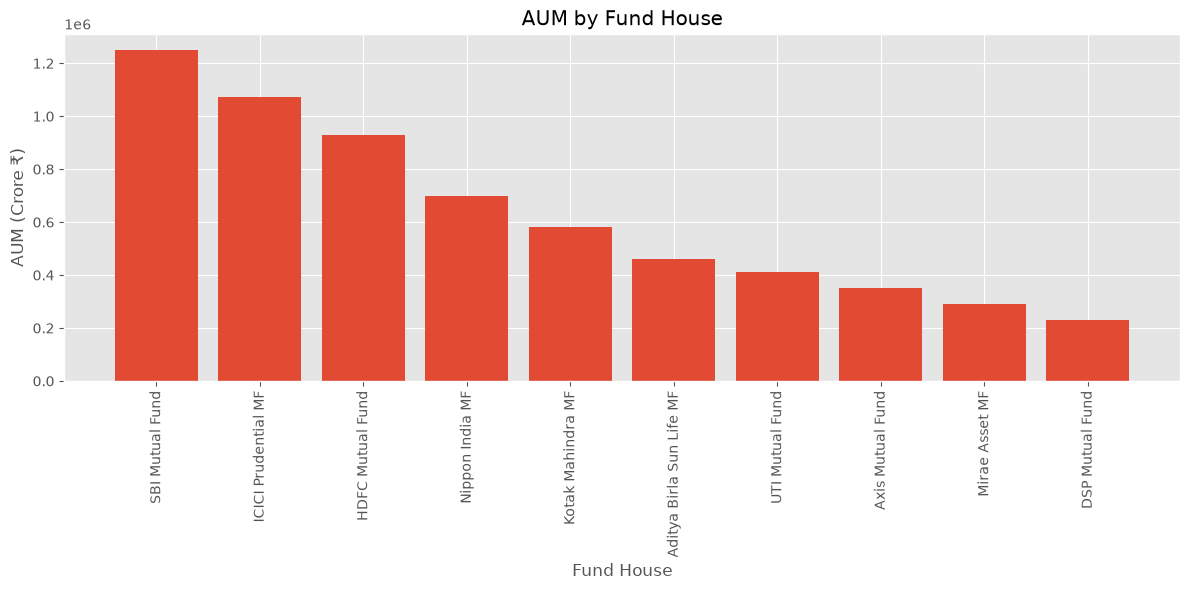

In [200]:
plt.figure(figsize=(12,6))

aum_sorted = aum.sort_values("aum_crore", ascending=False)

plt.bar(aum_sorted["fund_house"], aum_sorted["aum_crore"])

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.xlabel("Fund House")

plt.ylabel("AUM (Crore ₹)")

plt.tight_layout()

plt.show()

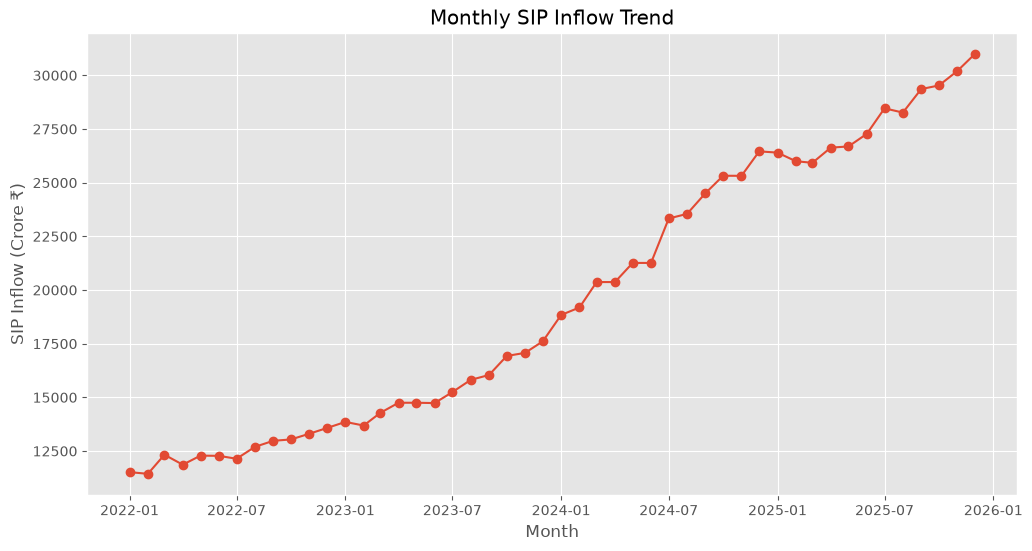

In [201]:
# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")

plt.xlabel("Month")

plt.ylabel("SIP Inflow (Crore ₹)")

plt.grid(True)

plt.show()

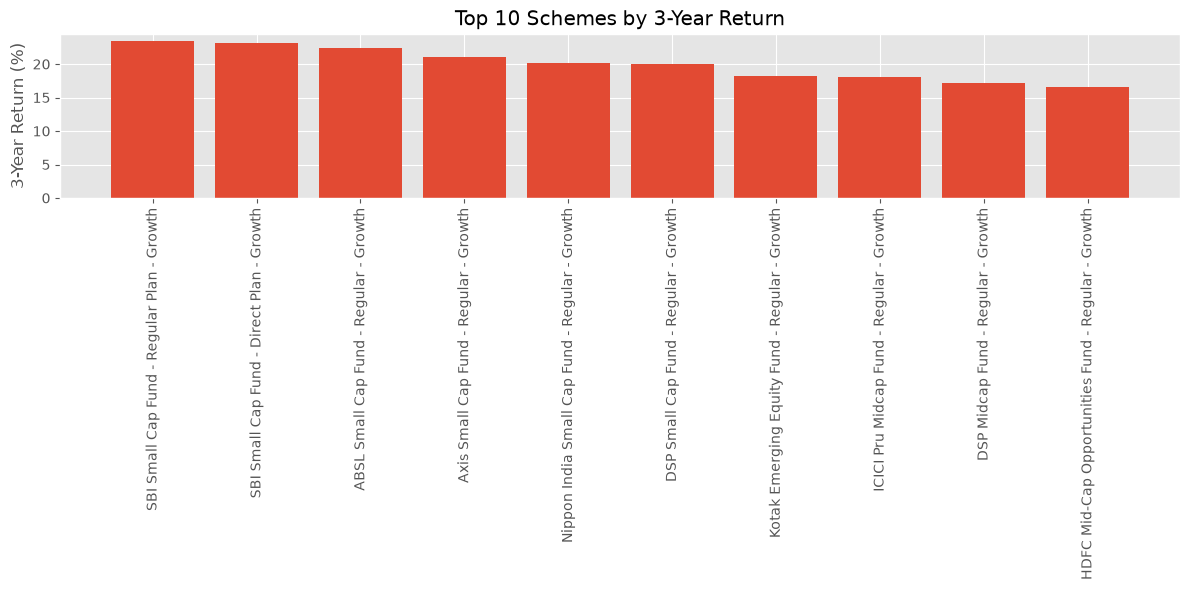

In [202]:
top10 = performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["return_3yr_pct"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Schemes by 3-Year Return")

plt.ylabel("3-Year Return (%)")

plt.tight_layout()

plt.show()

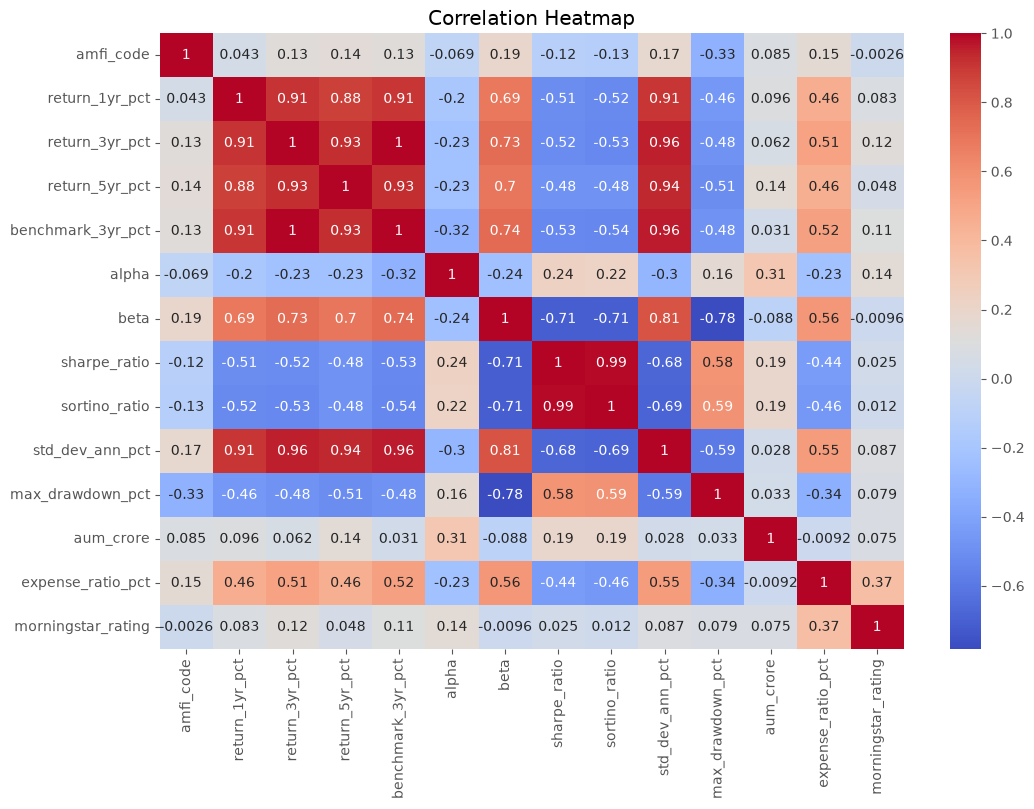

In [203]:
plt.figure(figsize=(12,8))

numeric = performance.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

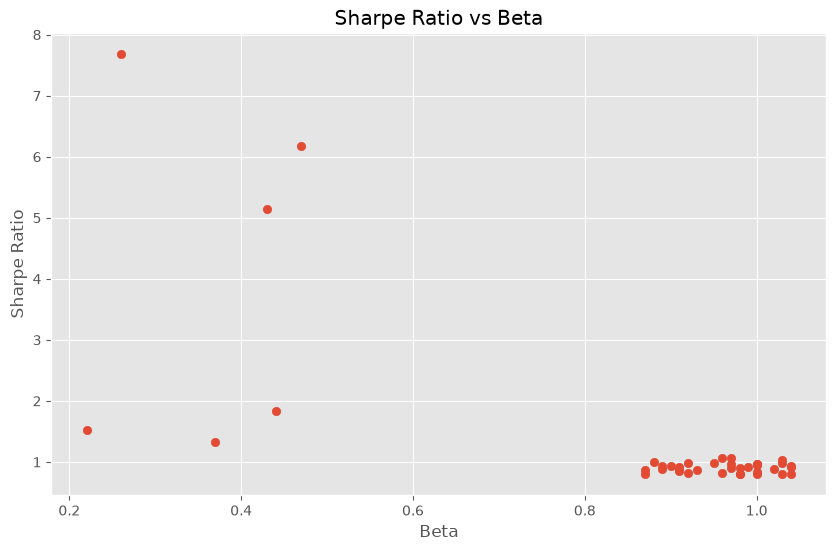

In [204]:
plt.figure(figsize=(10,6))

plt.scatter(
    performance["beta"],
    performance["sharpe_ratio"]
)

plt.title("Sharpe Ratio vs Beta")

plt.xlabel("Beta")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.show()

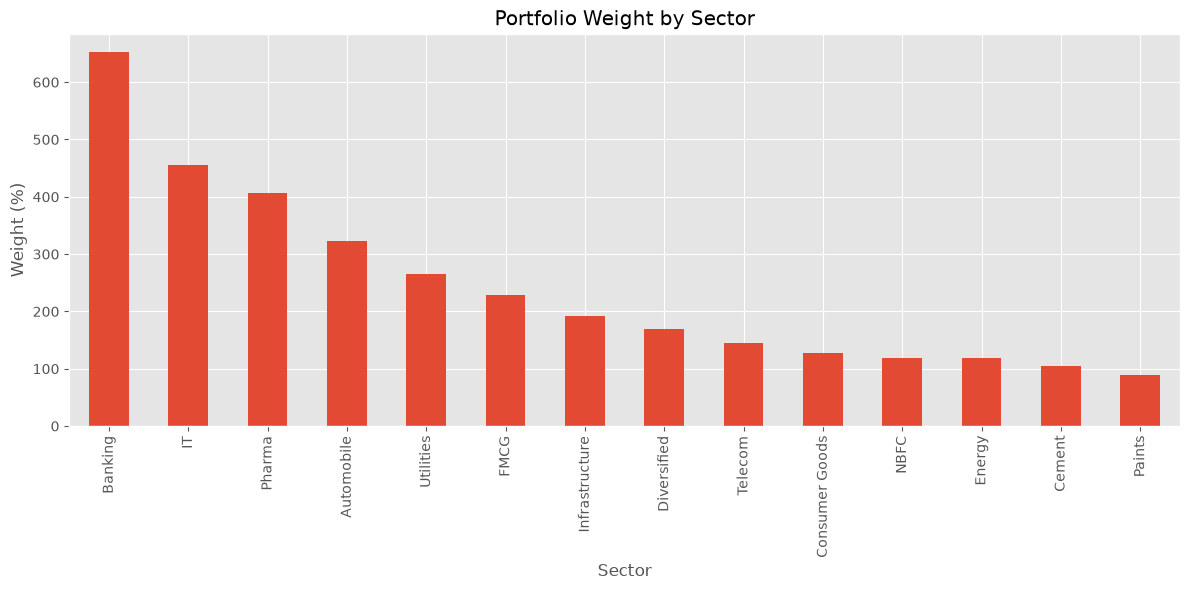

In [205]:
sector = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(12,6))

sector.sort_values(ascending=False).plot(kind="bar")

plt.title("Portfolio Weight by Sector")

plt.xlabel("Sector")

plt.ylabel("Weight (%)")

plt.tight_layout()

plt.show()

In [ ]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    format="mixed"
)

plt.figure(figsize=(12,6))

for index in benchmark["index_name"].unique():

    data = benchmark[
        benchmark["index_name"] == index
    ]

    plt.plot(
        data["date"],
        data["close_value"],
        label=index
    )

plt.title("Benchmark Index Performance")

plt.xlabel("Date")

plt.ylabel("Index Value")

plt.legend()

plt.grid(True)

plt.show()